In [3]:
#Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_DA_In = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

In [5]:
df_DA_In['job_posted_month_no'] = df_DA_In['job_posted_date'].dt.month

In [6]:
df_DA_explode = df_DA_In.explode('job_skills')

In [7]:
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

In [8]:
DA_totals = df_DA_In.groupby('job_posted_month_no').size()
df_DA_In_per = df_DA_pivot.div(DA_totals/100, axis=0)

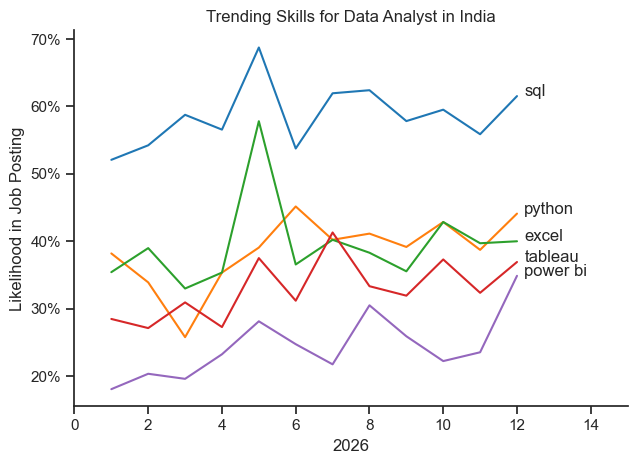

In [19]:
df_plot = df_DA_In_per.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Skills for Data Analyst in India')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2026')
plt.legend().remove()
plt.xlim(0, 15)
plt.tight_layout()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(12.2, df_plot.iloc[-1, i], df_plot.columns[i])